# Izma's Code

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 100)

In [4]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/airbnb/boston?select=listings.csv")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: izmakhurram
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/airbnb/boston


100%|██████████| 16.1M/16.1M [00:00<00:00, 781MB/s]

In [5]:
import os
os.listdir("boston")

['listings.csv', 'reviews.csv', 'calendar.csv']

# Data Understanding

In [6]:
airbnb_data = pd.read_csv('boston/listings.csv')
airbnb_data.shape

(3585, 95)

There are 3585 rows with 95 columns

In [7]:
airbnb_data.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'name', 'summary',
       'space', 'description', 'experiences_offered', 'neighborhood_overview',
       'notes', 'transit', 'access', 'interaction', 'house_rules',
       'thumbnail_url', 'medium_url', 'picture_url', 'xl_picture_url',
       'host_id', 'host_url', 'host_name', 'host_since', 'host_location',
       'host_about', 'host_response_time', 'host_response_rate',
       'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url',
       'host_picture_url', 'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'street',
       'neighbourhood', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'city', 'state', 'zipcode', 'market',
       'smart_location', 'country_code', 'country', 'latitude', 'longitude',
       'is_location_exact', 'property_type', 'room_type', 'accommodates',
       'bathrooms',

After going through columns, the main ones we need to include that may have impact on pricing are: listing_url, name, summary, description, host_is_superhost, neighbourhood, latitude, longitude, property_type, room_type, bathrooms, bedrooms, beds, amenities, price, review_scores_rating. We can remove other columns especially those with URLs, IDs, and images.

In [8]:
airbnb_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3585 entries, 0 to 3584
Data columns (total 95 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                3585 non-null   int64  
 1   listing_url                       3585 non-null   object 
 2   scrape_id                         3585 non-null   int64  
 3   last_scraped                      3585 non-null   object 
 4   name                              3585 non-null   object 
 5   summary                           3442 non-null   object 
 6   space                             2528 non-null   object 
 7   description                       3585 non-null   object 
 8   experiences_offered               3585 non-null   object 
 9   neighborhood_overview             2170 non-null   object 
 10  notes                             1610 non-null   object 
 11  transit                           2295 non-null   object 
 12  access

In [9]:
airbnb_data.head(5)

,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,notes,transit,access,interaction,house_rules,thumbnail_url,medium_url,picture_url,xl_picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,street,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,city,state,zipcode,market,smart_location,country_code,country,latitude,longitude,is_location_exact,property_type,room_type,accommodates,bathrooms,bedrooms,beds,bed_type,amenities,square_feet,price,weekly_price,monthly_price,security_deposit,cleaning_fee,guests_included,extra_people,minimum_nights,maximum_nights,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,requires_license,license,jurisdiction_names,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
0,12147973,https://www.airbnb.com/rooms/12147973,20160906204935,2016-09-07,Sunny Bungalow in the City,"Cozy, sunny, family home. Master bedroom high...",The house has an open and cozy feel at the sam...,"Cozy, sunny, family home. Master bedroom high...",none,"Roslindale is quiet, convenient and friendly. ...",NaN,"The bus stop is 2 blocks away, and frequent. B...","You will have access to 2 bedrooms, a living r...",NaN,Clean up and treat the home the way you'd like...,https://a2.muscache.com/im/pictures/c0842db1-e...,https://a2.muscache.com/im/pictures/c0842db1-e...,https://a2.muscache.com/im/pictures/c0842db1-e...,https://a2.muscache.com/im/pictures/c0842db1-e...,31303940,https://www.airbnb.com/users/show/31303940,Virginia,2015-04-15,"Boston, Massachusetts, United States",We are country and city connecting in our deck...,NaN,NaN,NaN,f,https://a2.muscache.com/im/pictures/5936fef0-b...,https://a2.muscache.com/im/pictures/5936fef0-b...,Roslindale,1,1,"['email', 'phone', 'facebook', 'reviews']",t,f,"Birch Street, Boston, MA 02131, United States",Roslindale,Roslindale,NaN,Boston,MA,02131,Boston,"Boston, MA",US,United States,42.282619,-71.133068,t,House,Entire home/apt,4,1.5,2.0,3.0,Real Bed,"{TV,""Wireless Internet"",Kitchen,""Free Parking ...",NaN,$250.00,NaN,NaN,NaN,$35.00,1,$0.00,2,1125,2 weeks ago,NaN,0,0,0,0,2016-09-06,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,NaN,NaN,f,moderate,f,f,1,NaN
1,3075044,https://www.airbnb.com/rooms/3075044,20160906204935,2016-09-07,Charming room in pet friendly apt,Charming and quiet room in a second floor 1910...,Small but cozy and quite room with a full size...,Charming and quiet room in a second floor 1910...,none,"The room is in Roslindale, a diverse and prima...","If you don't have a US cell phone, you can tex...",Plenty of safe street parking. Bus stops a few...,Apt has one more bedroom (which I use) and lar...,"If I am at home, I am likely working in my hom...",Pet friendly but please confirm with me if the...,https://a1.muscache.com/im/pictures/39327812/d...,https://a1.muscache.com/im/pictures/39327812/d...,https://a1.muscache.com/im/pictures/39327812/d...,https://a1.muscache.com/im/pictures/39327812/d...,2572247,https://www.airbnb.com/users/show/2572247,Andrea,2012-06-07,"Boston, Massachusetts, United States",I live in Boston and I like to travel and have...,within an hour,100%,100%,f,https://a2.muscache.com/im/users/2572247/profi...,https://a2.muscache.com/im/users/2572247/profi...,Roslindale,1,1,"['email', 'phone', 'facebook', 'linkedin', 'am...",t,t,"Pinehurst Street, Boston, MA 02131, United Sta

In [10]:
#summarizes numeric data only
airbnb_data.describe()

,id,scrape_id,host_id,host_listings_count,host_total_listings_count,neighbourhood_group_cleansed,latitude,longitude,accommodates,bathrooms,bedrooms,beds,square_feet,guests_included,minimum_nights,maximum_nights,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,jurisdiction_names,calculated_host_listings_count,reviews_per_month
count,3.585000e+03,3.585000e+03,3.585000e+03,3585.000000,3585.000000,0.0,3585.000000,3585.000000,3585.000000,3571.000000,3575.000000,3576.000000,56.000000,3585.000000,3585.000000,3.585000e+03,0.0,3585.00000,3585.000000,3585.000000,3585.000000,3585.000000,2772.000000,2762.000000,2767.000000,2765.000000,2767.000000,2763.000000,2764.000000,0.0,0.0,3585.000000,2829.000000
mean,8.440875e+06,2.016091e+13,2.492311e+07,58.902371,58.902371,NaN,42.340032,-71.084818,3.041283,1.221647,1.255944,1.609060,858.464286,1.429847,3.171269,2.872584e+04,NaN,8.64993,21.833194,38.558159,179.346444,19.044630,91.916667,9.431571,9.258041,9.646293,9.646549,9.414043,9.168234,NaN,NaN,12.733891,1.970908
std,4.500787e+06,8.516813e-01,2.292781e+07,171.119663,171.119663,NaN,0.024403,0.031565,1.778929,0.501487,0.753060,1.011745,608.874310,1.056787,8.874133,1.670136e+06,NaN,10.43533,21.860966,33.158272,142.136180,35.571658,9.531686,0.931863,1.168977,0.762753,0.735507,0.903436,1.011116,NaN,NaN,29.415076,2.120561
min,3.353000e+03,2.016091e+13,4.240000e+03,0.000000,0.000000,NaN,42.235942,-71.171789,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000e+00,NaN,0.00000,0.000000,0.000000,0.000000,0.000000,20.000000,2.000000,2.000000,2.000000,4.000000,2.000000,2.000000,NaN,NaN,1.000000,0.010000
25%,4.679319e+06,2.016091e+13,6.103425e+06,1.000000,1.000000,NaN,42.329995,-71.105083,2.000000,1.000000,1.000000,1.000000,415.000000,1.000000,1.000000,3.650000e+02,NaN,0.00000,0.000000,0.000000,19.000000,1.000000,89.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,NaN,NaN,1.000000,0.480000
50%,8.577620e+06,2.016091e+13,1.928100e+07,2.000000,2.000000,NaN,42.345201,-71.078429,2.000000,1.000000,1.000000,1.000000,825.000000,1.000000,2.000000,1.125000e+03,NaN,4.00000,16.000000,37.000000,179.000000,5.000000,94.000000,10.000000,10.000000,10.000000,10.000000,10.000000,9.000000,NaN,NaN,2.000000,1.170000
75%,1.278953e+07,2.016091e+13,3.622147e+07,7.000000,7.000000,NaN,42.354685,-71.062155,4.000000,1.000000,2.000000,2.000000,1200.000000,1.000000,3.000000,1.125000e+03,NaN,15.00000,40.000000,68.000000,325.000000,21.000000,98.250000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,NaN,NaN,6.000000,2.720000
max,1.493346e+07,2.016091e+13,9.385411e+07,749.000000,749.000000,NaN,42.389982,-71.000100,16.000000,6.000000,5.000000,16.000000,2400.000000,14.000000,300.000000,1.000000e+08,NaN,30.00000,60.000000,90.000000,365.000000,404.000000,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,NaN,NaN,136.000000,19.150000


In [11]:
#finding duplicates
airbnb_data.duplicated().sum()

np.int64(0)

There are no duplicates

In [12]:
#finding number of missing values
airbnb_data.isna().sum().sort_values(ascending=False)

,0
jurisdiction_names,3585
license,3585
neighbourhood_group_cleansed,3585
has_availability,3585
square_feet,3529
...,...
instant_bookable,0
cancellation_policy,0
require_guest_profile_picture,0
require_guest_phone_verification,0


There are missing values in various columns

What to do with duplicates in columns like summary, name, amenities, description?

In [13]:
airbnb_data['name'].duplicated().sum()

np.int64(81)

# Data Cleaning

Now, we can start cleaning the data. First, lets drop the columns we don't want to use.

In [14]:
#Identify key features (location, room type, bedrooms, price, reviews, etc.)
airbnb_data = airbnb_data[[
    #'id', 'listing_url',
    #'scrape_id', 'last_scraped',
    'name',
    'summary',
    #'space',
    'description',
    #'experiences_offered', 'neighborhood_overview',
      # 'notes', 'transit', 'access', 'interaction', 'house_rules',
      # 'thumbnail_url', 'medium_url', 'picture_url', 'xl_picture_url',
       #'host_id',
      #'host_url',
      #'host_name',
      #'host_since', 'host_location',
      # 'host_about', 'host_response_time', 'host_response_rate',
      # 'host_acceptance_rate',
    'host_is_superhost',
    #'host_thumbnail_url',
      # 'host_picture_url', 'host_neighbourhood',
    'host_listings_count',
      # 'host_total_listings_count', 'host_verifications',
      # 'host_has_profile_pic', 'host_identity_verified', 'street',
       'neighbourhood',
    #'neighbourhood_cleansed',
     #  'neighbourhood_group_cleansed', 'city',
    #'state', 'zipcode', 'market',
      # 'smart_location', 'country_code', 'country',
    'latitude', 'longitude',
       #'is_location_exact',
    'property_type',
    'room_type',
    'accommodates',
       'bathrooms', 'bedrooms',
    'beds',
    #'bed_type',
    'amenities', #'square_feet',
       'price',
    #'weekly_price', 'monthly_price', 'security_deposit',
     #  'cleaning_fee', 'guests_included', 'extra_people', 'minimum_nights',
     #  'maximum_nights', 'calendar_updated', 'has_availability',
     #  'availability_30', 'availability_60', 'availability_90',
     #  'availability_365', 'calendar_last_scraped',
    'number_of_reviews',
      # 'first_review', 'last_review',
    'review_scores_rating',
      # 'review_scores_accuracy', 'review_scores_cleanliness',
      # 'review_scores_checkin', 'review_scores_communication',
      # 'review_scores_location',
    #'review_scores_value'
    #'requires_license',
      # 'license', 'jurisdiction_names', 'instant_bookable',
      'cancellation_policy',
    #'require_guest_profile_picture',
      # 'require_guest_phone_verification', 'calculated_host_listings_count',
       #'reviews_per_month'
    ]].copy()

Add city column

In [15]:
airbnb_data['city'] = "Boston"

In [16]:
airbnb_data.columns

Index(['name', 'summary', 'description', 'host_is_superhost',
       'host_listings_count', 'neighbourhood', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms',
       'beds', 'amenities', 'price', 'number_of_reviews',
       'review_scores_rating', 'cancellation_policy', 'city'],
      dtype='object')

In [17]:
airbnb_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3585 entries, 0 to 3584
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  3585 non-null   object 
 1   summary               3442 non-null   object 
 2   description           3585 non-null   object 
 3   host_is_superhost     3585 non-null   object 
 4   host_listings_count   3585 non-null   int64  
 5   neighbourhood         3042 non-null   object 
 6   latitude              3585 non-null   float64
 7   longitude             3585 non-null   float64
 8   property_type         3582 non-null   object 
 9   room_type             3585 non-null   object 
 10  accommodates          3585 non-null   int64  
 11  bathrooms             3571 non-null   float64
 12  bedrooms              3575 non-null   float64
 13  beds                  3576 non-null   float64
 14  amenities             3585 non-null   object 
 15  price                

In [18]:
#Identify missing values
airbnb_data.isna().sum()

,0
name,0
summary,143
description,0
host_is_superhost,0
host_listings_count,0
neighbourhood,543
latitude,0
longitude,0
property_type,3
room_type,0


Before we handle the missing values, I will make a column that flags any rows where the columns are missing so we know what was filled.

In [19]:
airbnb_data['missing_flag'] = airbnb_data.isna().any(axis=1).astype(int)
airbnb_data['missing_flag'].value_counts()

,count
missing_flag,
0,2234
1,1351


Now, let's handle missing values in the columns. For numeric columns that are skewed we can replace missing values with the median and for categorical columns we can replace with the mode. We will skip over summary missing values since there is no mode.

In [20]:
numeric_cols = airbnb_data.select_dtypes(include="number")
airbnb_data[numeric_cols.columns] = numeric_cols.fillna(numeric_cols.median())
airbnb_data['property_type'] = airbnb_data['property_type'].fillna(airbnb_data['property_type'].mode()[0])
airbnb_data['neighbourhood'] = airbnb_data['neighbourhood'].fillna(airbnb_data['neighbourhood'].mode()[0])

In [21]:
airbnb_data.isna().sum()

,0
name,0
summary,143
description,0
host_is_superhost,0
host_listings_count,0
neighbourhood,0
latitude,0
longitude,0
property_type,0
room_type,0


All missing values are handled (except summary which we intentionally didn't handle)

After analyzing the data types of the columns, it seems that the price column is not a numeric data type so we will have to convert it first to use it.

In [22]:
airbnb_data['price'].isna().sum()
airbnb_data['price'] = (
    airbnb_data['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)
airbnb_data['price'].dtypes

dtype('float64')

Price is succesfully converted to a numeric data type.

We also want to adjust the review scores rating values from being ranged 0-100 to 0-1.

In [23]:
airbnb_data['review_scores_rating'] = airbnb_data['review_scores_rating'] / 100
airbnb_data['review_scores_rating']

,review_scores_rating
0,0.94
1,0.94
2,0.98
3,1.00
4,0.99
...,...
3580,0.90
3581,0.94
3582,0.94
3583,0.90


In [24]:
airbnb_data['price'].describe()

,price
count,3585.000000
mean,173.925802
std,148.331321
min,10.000000
25%,85.000000
50%,150.000000
75%,220.000000
max,4000.000000


The target (price) distribution shows that the average price is 173.9 for the listings with a min of 10 and max of 4000 (this is price per night). Since the standard deviation is 148 this shows that there could be one or more outlier in price since the max is 4000. Since the min is 10 it seems there are no pricings listed as 0.

We can better see the price distribution through a histogram.

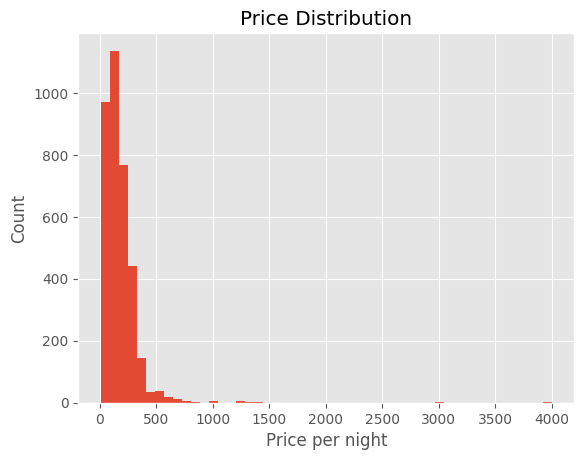

In [25]:
plt.hist(airbnb_data['price'], bins=50)
plt.xlabel("Price per night")
plt.title("Price Distribution")
plt.ylabel("Count")
plt.show()

Price is skewed left. There are also outliers above 1000. We can try a log transformation on price and see if it fixes the skew.

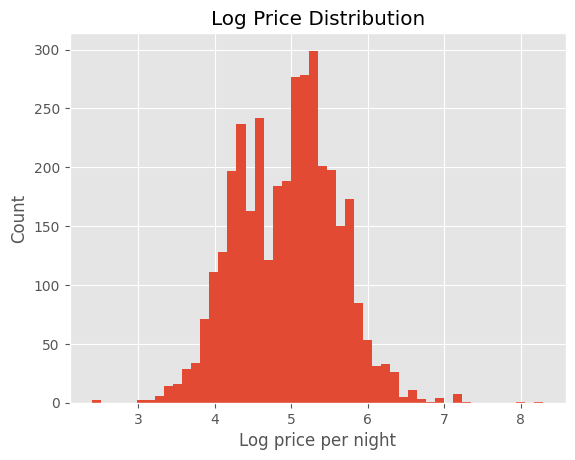

In [26]:
plt.hist(np.log1p(airbnb_data['price']), bins=50)
plt.title("Log Price Distribution")
plt.xlabel("Log price per night")
plt.ylabel("Count")
plt.show()

The skew is fixed after applying a log transform. We also see that their is an outlier at a lower price too.

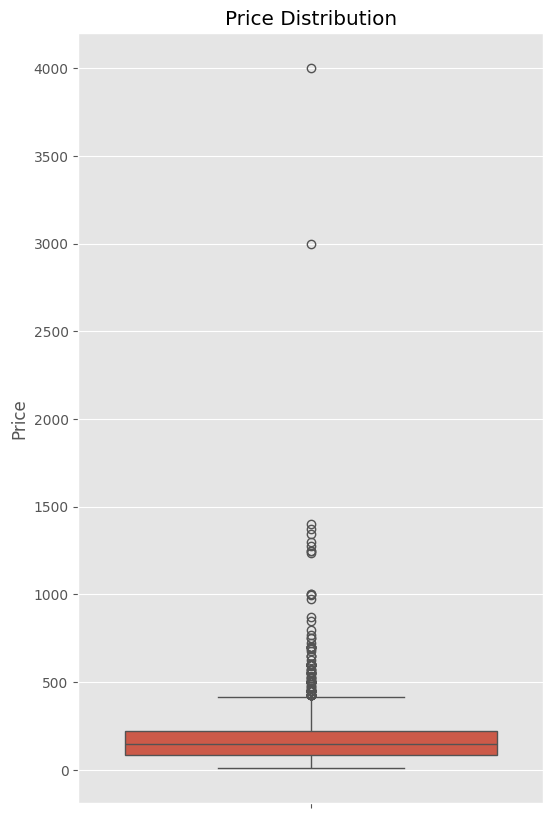

In [27]:
plt.figure(figsize=(6, 10))
sns.boxplot(y=airbnb_data['price'])   # y-axis = numeric variable
plt.title('Price Distribution')
plt.ylabel('Price')
plt.show()

To ensure better analysis I am going to take out the top 10 outliers using the 95th percentile rule.



#HERE

In [28]:
airbnb_data['price'].nlargest(10)

,price
2285,4000.0
3055,3000.0
793,1400.0
2204,1372.0
1950,1345.0
1022,1300.0
2448,1275.0
1262,1250.0
3096,1250.0
1896,1235.0


In [29]:
upper_threshold = airbnb_data['price'].quantile(0.95)
airbnb_data = airbnb_data[airbnb_data['price'] <= upper_threshold]

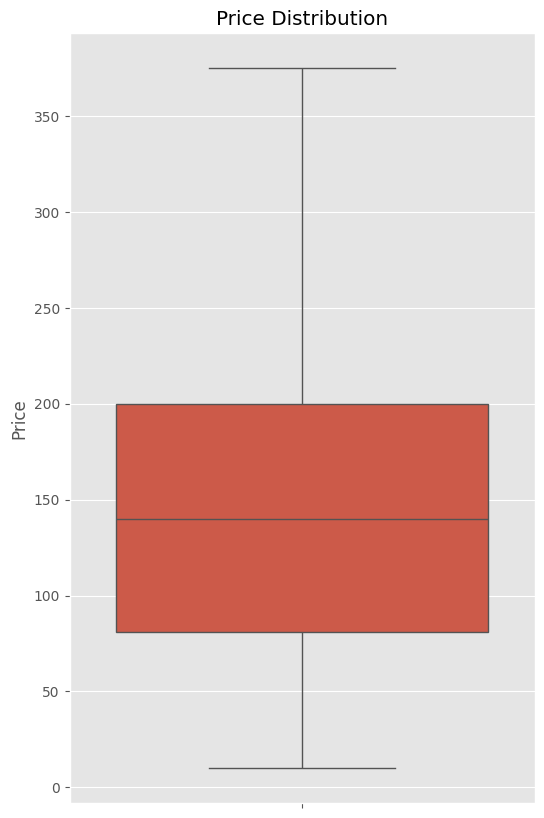

In [30]:
plt.figure(figsize=(6, 10))
sns.boxplot(y=airbnb_data['price'])   # y-axis = numeric variable
plt.title('Price Distribution')
plt.ylabel('Price')
plt.show()

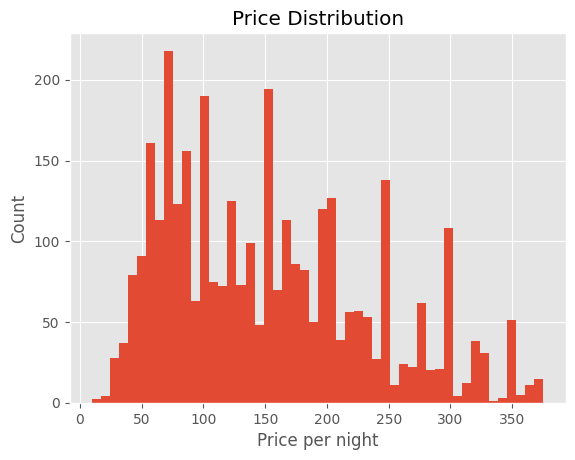

In [31]:
plt.hist(airbnb_data['price'], bins=50)
plt.xlabel("Price per night")
plt.title("Price Distribution")
plt.ylabel("Count")
plt.show()

# Feature Understanding


Now let's see the distributions and relationships between various columns in the dataset and how they affect price.

### Categorical Counts

Let's start with counts of the categorical data in bar charts. This includes room_type, property_type, host_is_superhost, cancellation_policy and neighbourhood.

In [32]:
airbnb_data.dtypes

,0
name,object
summary,object
description,object
host_is_superhost,object
host_listings_count,int64
neighbourhood,object
latitude,float64
longitude,float64
property_type,object
room_type,object


Room Type Analysis

In [33]:
airbnb_data['room_type'].value_counts()

,count
room_type,
Entire home/apt,1965
Private room,1366
Shared room,77


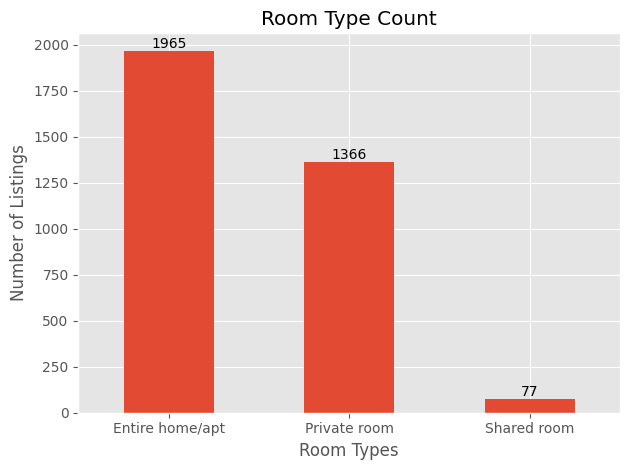

In [34]:
room_plot = airbnb_data['room_type'].value_counts() \
.plot(kind = 'bar', title = "Room Type Count")
room_plot.set_ylabel("Number of Listings")
room_plot.set_xlabel("Room Types")
plt.xticks(rotation=0)
for i in room_plot.containers:
    room_plot.bar_label(i, fmt='%.f')
plt.tight_layout()

Shared room is the least popular.

Property Type Analysis

In [35]:
airbnb_data['property_type'].value_counts()

,count
property_type,
Apartment,2498
House,531
Condominium,214
Townhouse,51
Bed & Breakfast,41
Loft,36
Other,13
Boat,11
Villa,5


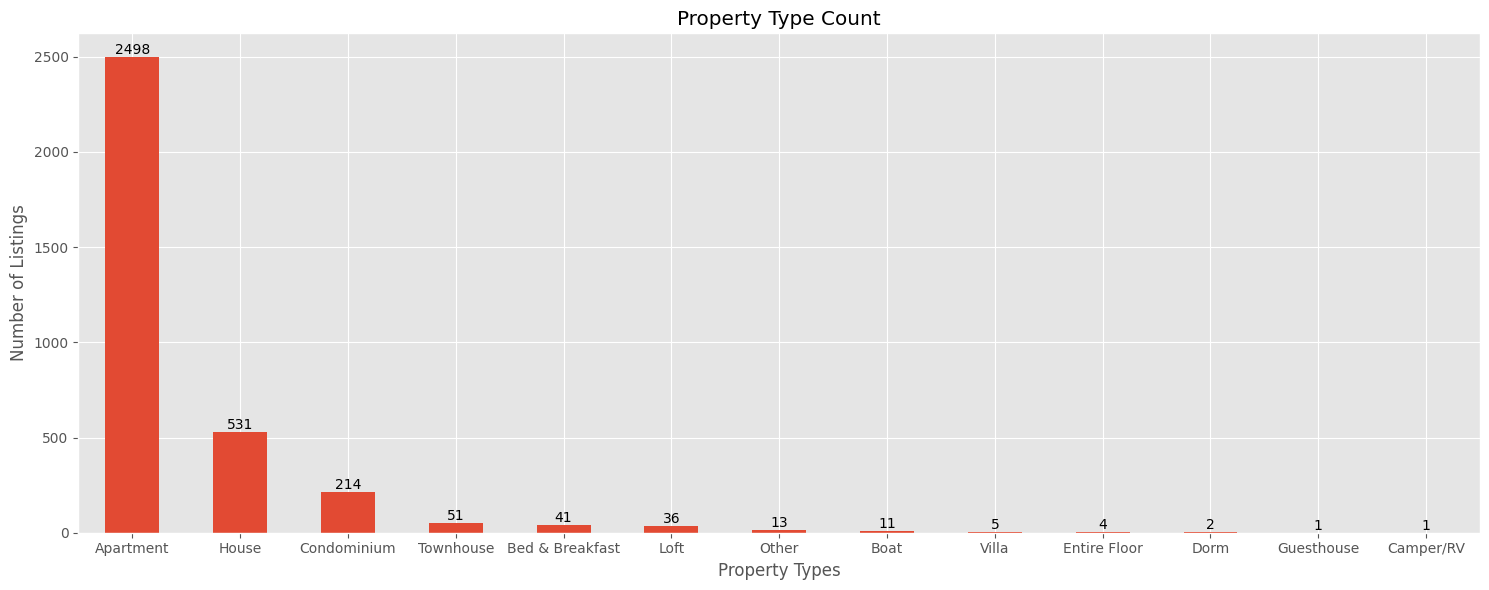

In [36]:
property_plot = airbnb_data['property_type'].value_counts() \
.plot(kind = 'bar', title = "Property Type Count", figsize=(15,6))
property_plot.set_ylabel("Number of Listings")
property_plot.set_xlabel("Property Types")
plt.xticks(rotation=0)
for i in property_plot.containers:
    property_plot.bar_label(i, fmt='%.f')
plt.tight_layout()

The property types of guesthouse, camper/rv, dorm, entire floor, boat, and villa seem to be outliers and can be combined with other. The most common type is an apartment.

Superhost Analysis

In [37]:
airbnb_data['host_is_superhost'].value_counts()

,count
host_is_superhost,
f,3031
t,377


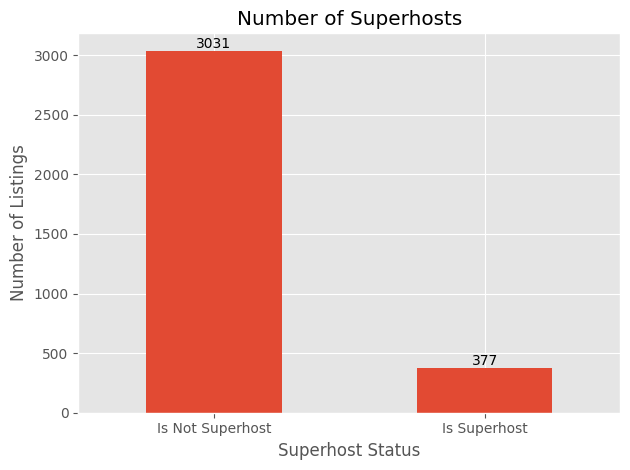

In [38]:
superhost_plot = airbnb_data['host_is_superhost'].value_counts() \
.plot(kind = 'bar', title = "Number of Superhosts")
superhost_plot.set_ylabel("Number of Listings")
superhost_plot.set_xlabel("Superhost Status")
plt.xticks(rotation=0)
superhost_plot.set_xticklabels(['Is Not Superhost', 'Is Superhost'])
for i in superhost_plot.containers:
    superhost_plot.bar_label(i, fmt='%.f')
plt.tight_layout()

Most hosts are not superhosts.

Cancellation Policy Analysis

In [39]:
airbnb_data['cancellation_policy'].value_counts()

,count
cancellation_policy,
strict,1497
flexible,954
moderate,882
super_strict_30,75


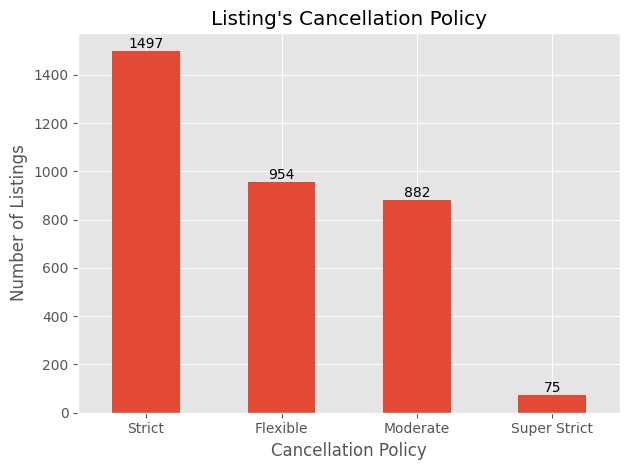

In [40]:
cancel_plot = airbnb_data['cancellation_policy'].value_counts() \
.plot(kind = 'bar', title = "Listing's Cancellation Policy")
cancel_plot.set_ylabel("Number of Listings")
cancel_plot.set_xlabel("Cancellation Policy")
plt.xticks(rotation=0)
cancel_plot.set_xticklabels(['Strict', 'Flexible', 'Moderate', 'Super Strict'])
for i in cancel_plot.containers:
    cancel_plot.bar_label(i, fmt='%.f')
plt.tight_layout()

Neighbourhood Analysis

In [41]:
airbnb_data['neighbourhood'].value_counts()

,count
neighbourhood,
Allston-Brighton,881
Jamaica Plain,299
South End,280
Back Bay,259
Fenway/Kenmore,237
Dorchester,194
South Boston,191
Beacon Hill,164
North End,118


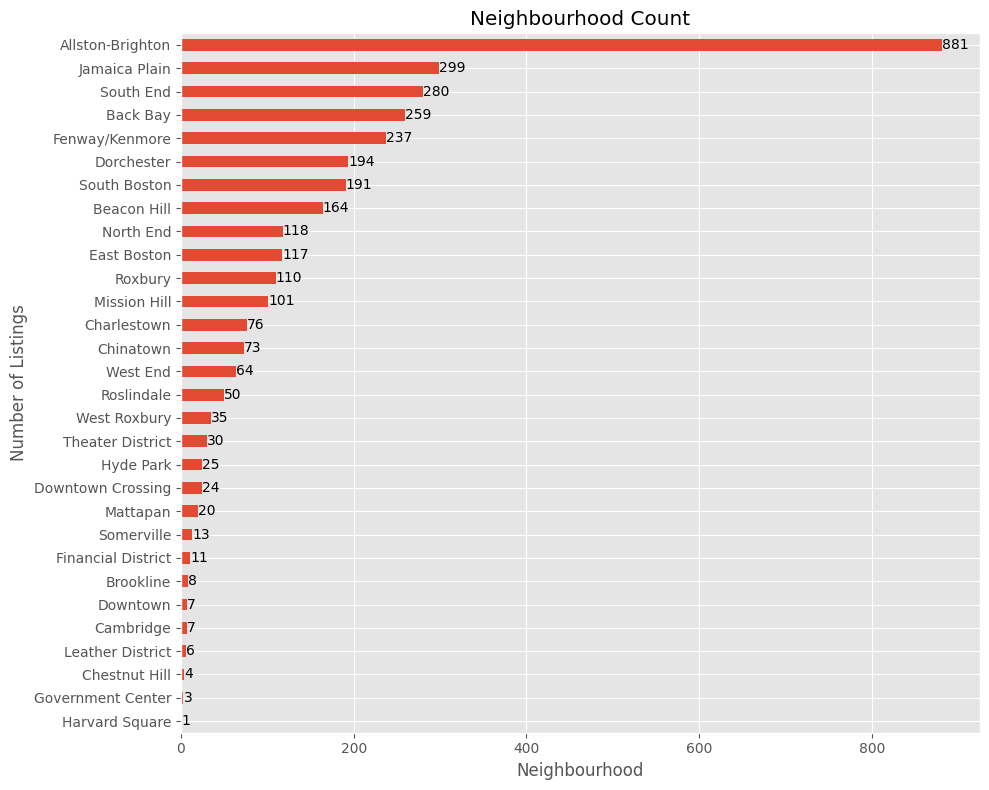

In [42]:
neighborhood_plot = airbnb_data['neighbourhood'].value_counts().sort_values(ascending=True) \
.plot(kind = 'barh', title = "Neighbourhood Count", figsize=(10,8))
neighborhood_plot.set_ylabel("Number of Listings")
neighborhood_plot.set_xlabel("Neighbourhood")
for i in neighborhood_plot.containers:
    neighborhood_plot.bar_label(i, fmt='%.f')
plt.tight_layout()

The neighbourhoods seems to have some categories with barely any listings that can either be removed or put into a "other" category. However, specific neighborhoods could impact pricing. The most common neighborhood is Aliston-Brighton.

### Basic Numeric Plots

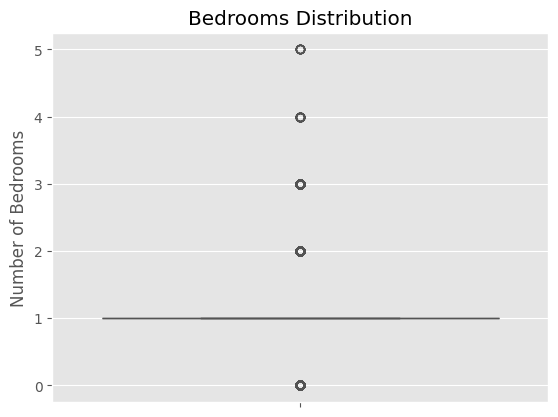

In [43]:
plt.figure()
sns.boxplot(y=airbnb_data['bedrooms'])
plt.title('Bedrooms Distribution')
plt.ylabel('Number of Bedrooms')
plt.show()

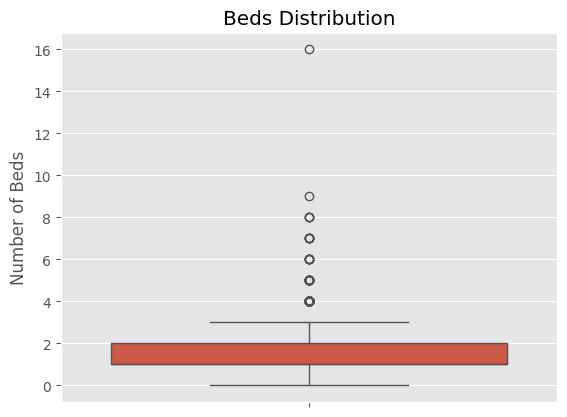

In [44]:
plt.figure()
sns.boxplot(y=airbnb_data['beds'])
plt.title('Beds Distribution')
plt.ylabel('Number of Beds')
plt.show()

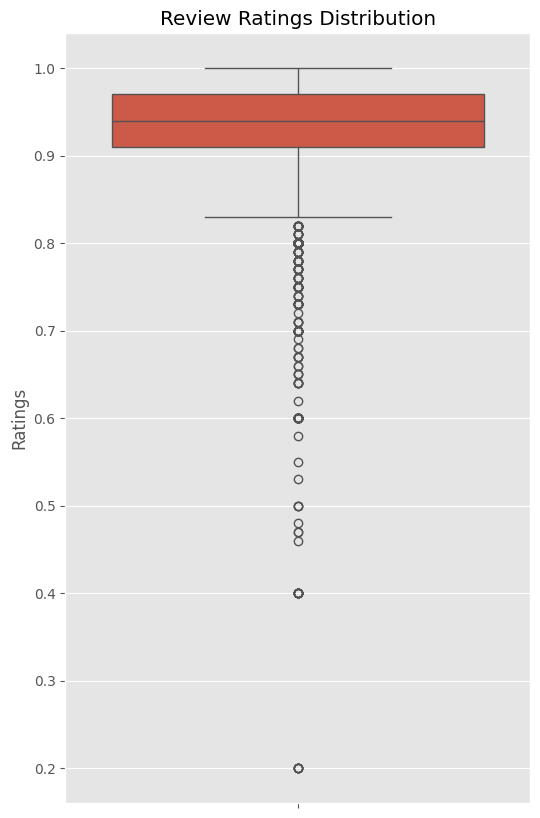

In [45]:
plt.figure(figsize=(6,10))
sns.boxplot(y=airbnb_data['review_scores_rating'])
plt.title('Review Ratings Distribution')
plt.ylabel('Ratings')
plt.show()

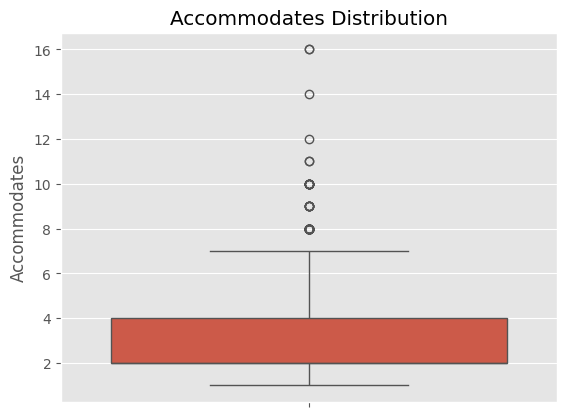

In [46]:
plt.figure()
sns.boxplot(y=airbnb_data['accommodates'])
plt.title('Accommodates Distribution')
plt.ylabel('Accommodates')
plt.show()

### Price Relationships

Now let's look at how price is affected by various parameters.

Let's start with a correlation heatmap of all numeric values.

In [47]:
df_corr = airbnb_data[['accommodates','bathrooms','bedrooms','beds','review_scores_rating','price']].corr()
df_corr

,accommodates,bathrooms,bedrooms,beds,review_scores_rating,price
accommodates,1.000000,0.253481,0.676823,0.789001,0.025157,0.550736
bathrooms,0.253481,1.000000,0.345636,0.249246,-0.013574,0.147421
bedrooms,0.676823,0.345636,1.000000,0.657866,0.042677,0.400286
beds,0.789001,0.249246,0.657866,1.000000,0.018804,0.401038
review_scores_rating,0.025157,-0.013574,0.042677,0.018804,1.000000,0.091986
price,0.550736,0.147421,0.400286,0.401038,0.091986,1.000000


<Axes: >

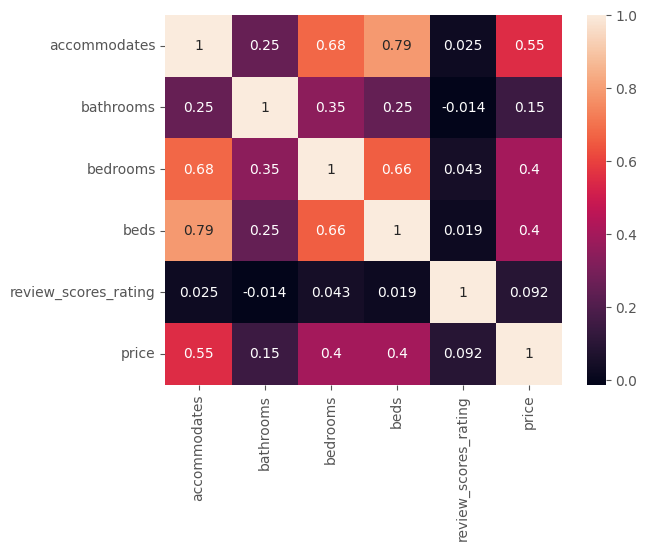

In [48]:
sns.heatmap(df_corr, annot=True)

As we see by the heatmap the strongest correlations are between beds and accomodates, bedrooms and beds, and price has the highest correlation with accomodates and bedrooms/beds.

Now let's compare room type and price.

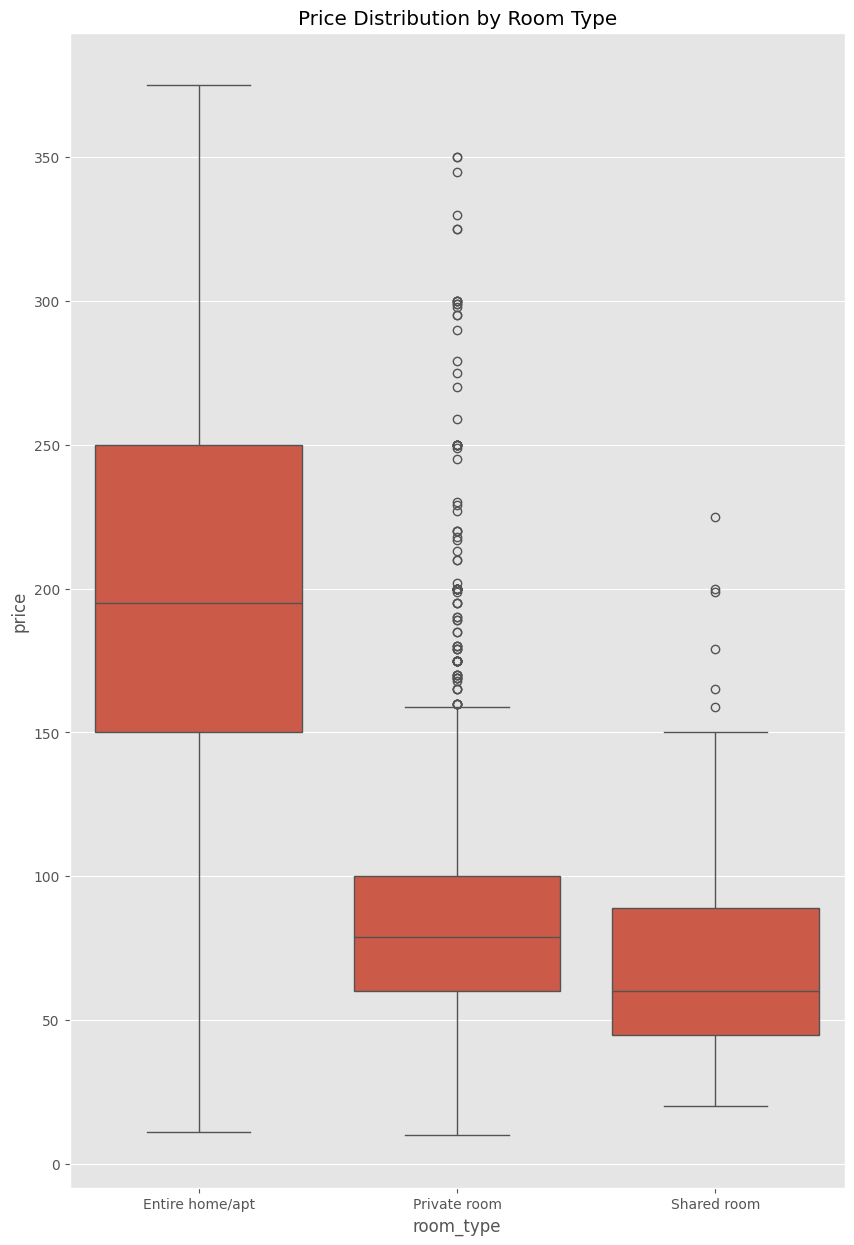

In [49]:
plt.figure(figsize=(10, 15))
sns.boxplot(
    x='room_type',
    y='price',
    data=airbnb_data
)
plt.title('Price Distribution by Room Type')
plt.show()

We can cleary see the outliers for each room type here. The most expensive listings are the entire home/apt.

Let's compare price and accomodates.


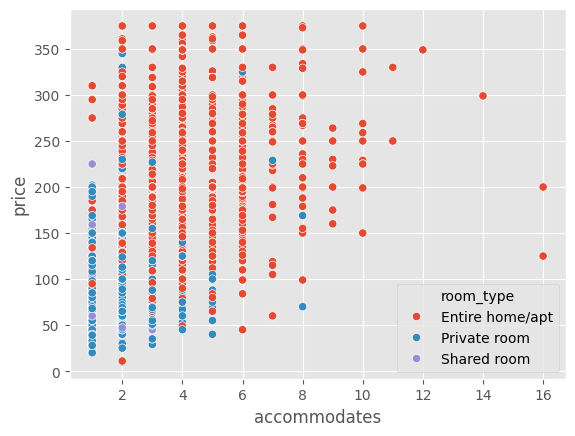

In [50]:
sns.scatterplot(x='accommodates',
                y='price',
                hue='room_type',
                data=airbnb_data)
plt.show()

Price tends to increase as accomodates increases.

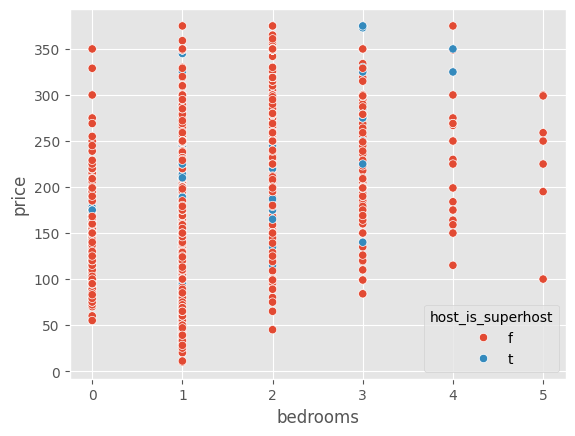

In [51]:
sns.scatterplot(x='bedrooms',
                y='price',
                hue='host_is_superhost',
                data=airbnb_data)
plt.show()

Let's see the average price in each neighbourhood.

In [52]:
avg_price_by_neighborhood = airbnb_data.groupby('neighbourhood')['price'].mean()
print(avg_price_by_neighborhood)

neighbourhood
Allston-Brighton      123.881952
Back Bay              210.667954
Beacon Hill           186.890244
Brookline             130.375000
Cambridge             203.000000
Charlestown           190.723684
Chestnut Hill          70.750000
Chinatown             224.835616
Dorchester             95.917526
Downtown              167.428571
Downtown Crossing     260.916667
East Boston           124.059829
Fenway/Kenmore        193.632911
Financial District    262.636364
Government Center     205.333333
Harvard Square        259.000000
Hyde Park              93.680000
Jamaica Plain         122.528428
Leather District      196.166667
Mattapan               72.000000
Mission Hill          117.752475
North End             181.788136
Roslindale             99.160000
Roxbury               120.136364
Somerville             93.076923
South Boston          178.376963
South End             182.864286
Theater District      207.566667
West End              209.515625
West Roxbury          111.342

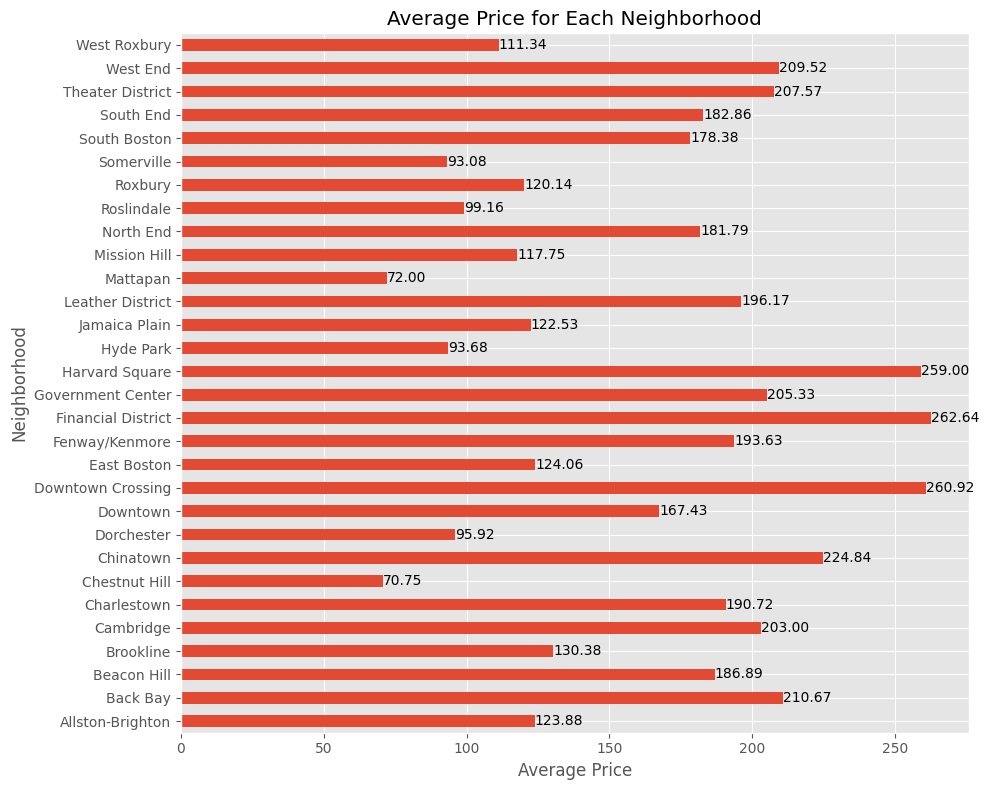

In [53]:
avgn_plot = avg_price_by_neighborhood.plot(kind = 'barh',
                                           title = "Average Price for Each Neighborhood",
                                           figsize=(10,8))
avgn_plot.set_ylabel("Neighborhood")
avgn_plot.set_xlabel("Average Price")
plt.xticks(rotation=0)
for i in avgn_plot.containers:
    avgn_plot.bar_label(i, fmt='%.2f')
plt.tight_layout()

We see the most expensive neighborhood is Harvard Square and the cheapest neighborhood is Chestnut Hill and Mattapan.

Let's see the average price for the accommodates and room type.

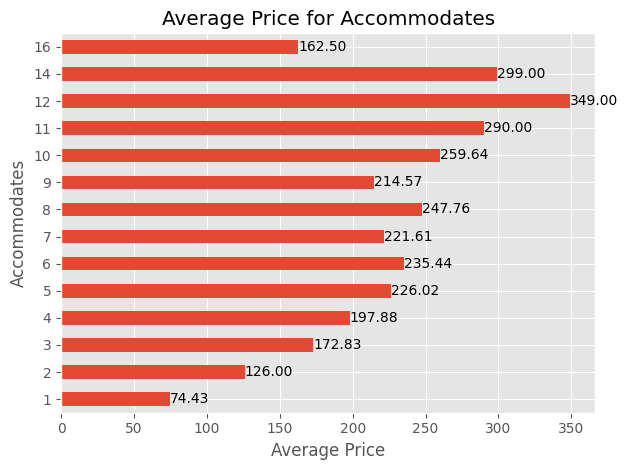

In [54]:
avg_price_by_acc = airbnb_data.groupby('accommodates')['price'].mean()
avgb = avg_price_by_acc.plot(kind = 'barh', title = "Average Price for Accommodates")
avgb.set_ylabel("Accommodates")
avgb.set_xlabel("Average Price")
for i in avgb.containers:
    avgb.bar_label(i, fmt='%.2f')
plt.tight_layout()

Price tends to increase with accommodates.

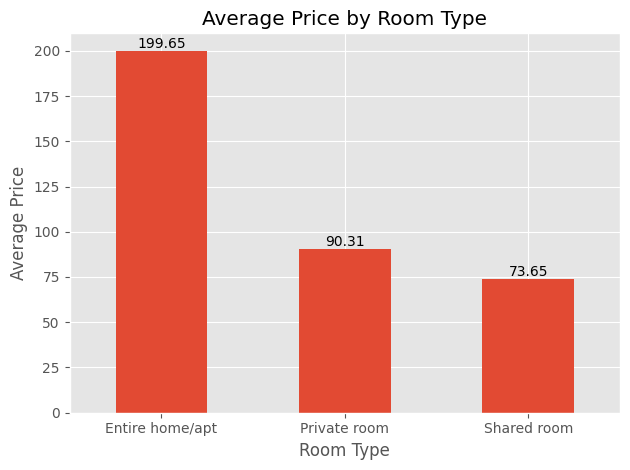

In [55]:
avg_price_by_rtype = airbnb_data.groupby('room_type')['price'].mean()
avgr = avg_price_by_rtype.plot(kind = 'bar', title = "Average Price by Room Type")
avgr.set_ylabel("Average Price")
avgr.set_xlabel("Room Type")
plt.xticks(rotation=0)
for i in avgr.containers:
    avgr.bar_label(i, fmt='%.2f')
plt.tight_layout()

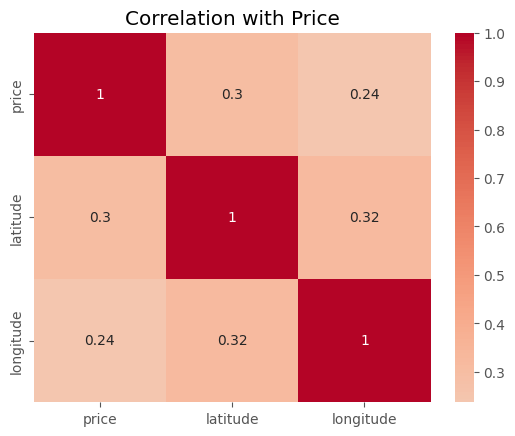

In [56]:
corr = airbnb_data[['price', 'latitude', 'longitude']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation with Price')
plt.show()

Other graphs

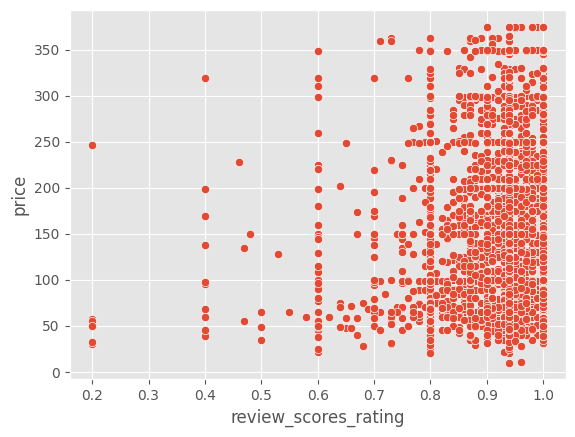

In [57]:
sns.scatterplot(x='review_scores_rating',
                y='price',
                data=airbnb_data)
plt.show()

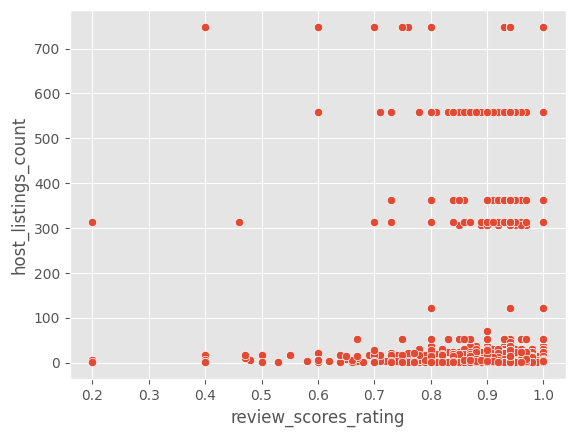

In [58]:
sns.scatterplot(x='review_scores_rating',
                y='host_listings_count',
                data=airbnb_data)
plt.show()

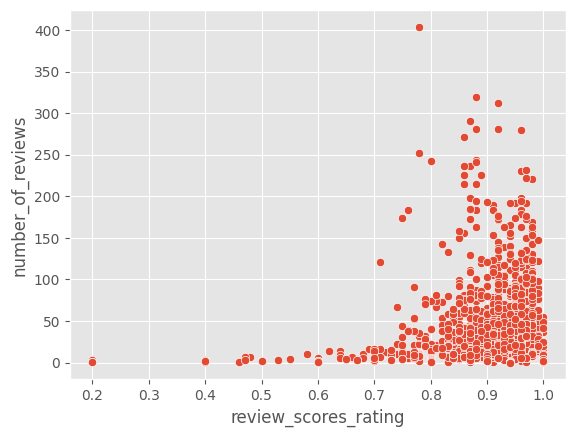

In [59]:
sns.scatterplot(x='review_scores_rating',
                y='number_of_reviews',
                data=airbnb_data)
plt.show()

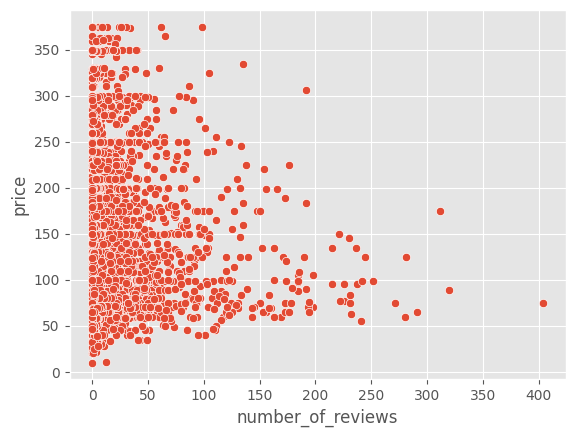

In [60]:
sns.scatterplot(x='number_of_reviews',
                y='price',
                data=airbnb_data)
plt.show()

It looks like as number of reviews increases the price decreases exponentially.

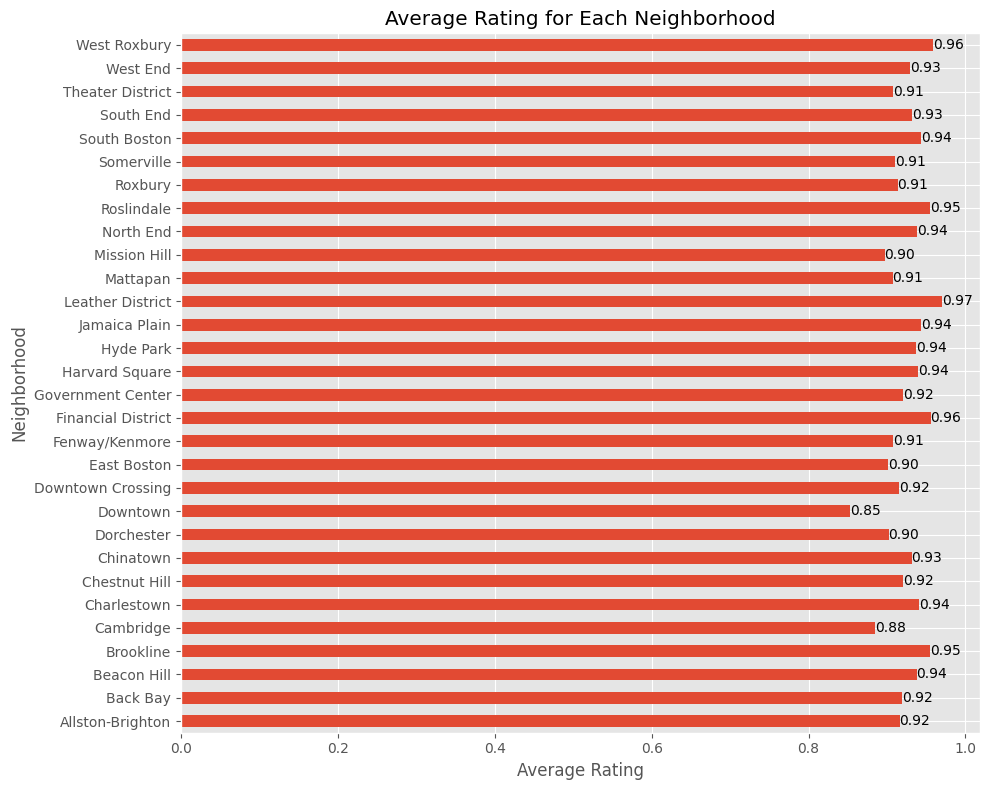

In [61]:
avg_price_by_neighborhood = airbnb_data.groupby('neighbourhood')['review_scores_rating'].mean()
avgn_plot = avg_price_by_neighborhood.plot(kind = 'barh',
                                           title = "Average Rating for Each Neighborhood",
                                           figsize=(10,8))
avgn_plot.set_ylabel("Neighborhood")
avgn_plot.set_xlabel("Average Rating")
plt.xticks(rotation=0)
for i in avgn_plot.containers:
    avgn_plot.bar_label(i, fmt='%.2f')
plt.tight_layout()

In [62]:
most_common_property = (
    airbnb_data.groupby('neighbourhood')['property_type']
    .agg(lambda x: x.mode()[0])   # take the first mode if multiple
)
print(most_common_property)

neighbourhood
Allston-Brighton      Apartment
Back Bay              Apartment
Beacon Hill           Apartment
Brookline             Apartment
Cambridge             Apartment
Charlestown           Apartment
Chestnut Hill         Apartment
Chinatown             Apartment
Dorchester            Apartment
Downtown              Apartment
Downtown Crossing     Apartment
East Boston           Apartment
Fenway/Kenmore        Apartment
Financial District    Apartment
Government Center     Apartment
Harvard Square        Apartment
Hyde Park                 House
Jamaica Plain         Apartment
Leather District      Apartment
Mattapan                  House
Mission Hill          Apartment
North End             Apartment
Roslindale                House
Roxbury               Apartment
Somerville            Apartment
South Boston          Apartment
South End             Apartment
Theater District      Apartment
West End              Apartment
West Roxbury              House
Name: property_type, dtype

In [63]:
airbnb_cleaned = airbnb_data[['name', #'summary', 'description', 'host_is_superhost',
       #'host_listings_count',
        'neighbourhood', 'latitude', 'longitude',
       #'property_type',
        'room_type', 'accommodates', 'bathrooms', 'bedrooms',
       'beds', #'amenities',
       'price', #'number_of_reviews',
       'review_scores_rating', #'cancellation_policy',
        'city', 'missing_flag']]
airbnb_cleaned.columns

Index(['name', 'neighbourhood', 'latitude', 'longitude', 'room_type',
       'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price',
       'review_scores_rating', 'city', 'missing_flag'],
      dtype='object')

In [67]:
airbnb_cleaned.to_csv("boston_clean.csv", index=False)

In [68]:
from google.colab import files
files.download("boston_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Encoding

We are going to one hot encode the categorical data in the dataset.

In [ ]:
airbnb_encoded = pd.get_dummies(airbnb_data, columns=['host_is_superhost', 'neighbourhood', 'property_type', 'room_type', 'cancellation_policy'], dtype=int)
airbnb_encoded.columns

Index(['name', 'summary', 'description', 'host_listings_count', 'latitude',
       'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
       'amenities', 'price', 'number_of_reviews', 'review_scores_rating',
       'city', 'missing_flag', 'host_is_superhost_f', 'host_is_superhost_t',
       'neighbourhood_Allston-Brighton', 'neighbourhood_Back Bay',
       'neighbourhood_Beacon Hill', 'neighbourhood_Brookline',
       'neighbourhood_Cambridge', 'neighbourhood_Charlestown',
       'neighbourhood_Chestnut Hill', 'neighbourhood_Chinatown',
       'neighbourhood_Dorchester', 'neighbourhood_Downtown',
       'neighbourhood_Downtown Crossing', 'neighbourhood_East Boston',
       'neighbourhood_Fenway/Kenmore', 'neighbourhood_Financial District',
       'neighbourhood_Government Center', 'neighbourhood_Harvard Square',
       'neighbourhood_Hyde Park', 'neighbourhood_Jamaica Plain',
       'neighbourhood_Leather District', 'neighbourhood_Mattapan',
       'neighbourhood_Mission Hil

In [ ]:
airbnb_encoded.head(5)

,name,summary,description,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,amenities,price,number_of_reviews,review_scores_rating,city,missing_flag,host_is_superhost_f,host_is_superhost_t,neighbourhood_Allston-Brighton,neighbourhood_Back Bay,neighbourhood_Beacon Hill,neighbourhood_Brookline,neighbourhood_Cambridge,neighbourhood_Charlestown,neighbourhood_Chestnut Hill,neighbourhood_Chinatown,neighbourhood_Dorchester,neighbourhood_Downtown,neighbourhood_Downtown Crossing,neighbourhood_East Boston,neighbourhood_Fenway/Kenmore,neighbourhood_Financial District,neighbourhood_Government Center,neighbourhood_Harvard Square,neighbourhood_Hyde Park,neighbourhood_Jamaica Plain,neighbourhood_Leather District,neighbourhood_Mattapan,neighbourhood_Mission Hill,neighbourhood_North End,neighbourhood_Roslindale,neighbourhood_Roxbury,neighbourhood_Somerville,neighbourhood_South Boston,neighbourhood_South End,neighbourhood_Theater District,neighbourhood_West End,neighbourhood_West Roxbury,property_type_Apartment,property_type_Bed & Breakfast,property_type_Boat,property_type_Camper/RV,property_type_Condominium,property_type_Dorm,property_type_Entire Floor,property_type_Guesthouse,property_type_House,property_type_Loft,property_type_Other,property_type_Townhouse,property_type_Villa,room_type_Entire home/apt,room_type_Private room,room_type_Shared room,cancellation_policy_flexible,cancellation_policy_moderate,cancellation_policy_strict,cancellation_policy_super_strict_30
0,Sunny Bungalow in the City,"Cozy, sunny, family home. Master bedroom high...","Cozy, sunny, family home. Master bedroom high...",1,42.282619,-71.133068,4,1.5,2.0,3.0,"{TV,""Wireless Internet"",Kitchen,""Free Parking ...",250.0,0,0.94,Boston,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0
1,Charming room in pet friendly apt,Charming and quiet room in a second floor 1910...,Charming and quiet room in a second floor 1910...,1,42.286241,-71.134374,2,1.0,1.0,1.0,"{TV,Internet,""Wireless Internet"",""Air Conditio...",65.0,36,0.94,Boston,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0
2,Mexican Folk Art Haven in Boston,"Come stay with a friendly, middle-aged guy in ...","Come stay with a friendly, middle-aged guy in ...",1,42.292438,-71.135765,2,1.0,1.0,1.0,"{TV,""Cable TV"",""Wireless Internet"",""Air Condit...",65.0,41,0.98,Boston,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0
3,Spacious Sunny Bedroom Suite in Historic Home,Come experience the comforts of home away from...,Come experience the comforts of home away from...,1,42.281106,-71.121021,4,1.0,1.0,2.0,"{TV,Internet,""Wireless Internet"",""Air Conditio...",75.0,1,1.00,Boston,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0
4,Come Home to Boston,"My comfy, clean and relaxing home is one block...","My comfy, clean and relaxing home is one block...",1,42.284512,-71.136258,2,1.5,1.0,2.0,"{Internet,""Wireless Internet"",""Air Conditionin...",79.0,29,0.99,Boston,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0
